## Module 0: Data curation with an emphasis on pre-processing medical images
Please refer to lectures 2 & 3 from Module 0. \\
Questions: Julia Cluceru (cluceru.julia@gene.com)


**Objectives (what will we learn here?)**


1.   Running a jupyter notebook in Google Colab
2.   Reading in high-resolution computed tomography (HRCT) NIfTI files, and saving the images as a numpy array
3.   Viewing slices of the HRCT lung volumes
4.   Applying a lung mask
5.   Re-sampling the spatial resolution of HRCT volume datasets


##Step 1: Set up the environment and determine where data is located

In [ ]:
#Load packages that are needed to view & process the imaging data
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
pip install nibabel #installing a library in python, use pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 32.5 MB/s eta 0:00:00


In [ ]:
import nibabel as nib #used particularly for nifti files

Connect to the data source:

In [ ]:
!apt-get update -y && apt-get install -y fuse lsb-release; \
    curl -L -O https://github.com/GoogleCloudPlatform/gcsfuse/releases/download/v1.4.0/gcsfuse_1.4.0_amd64.deb; \
    dpkg --install gcsfuse_1.4.0_amd64.deb; \
    apt-get update; \
    apt-get clean;

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,658 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,680 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,526 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,911 kB]
Fetched 16.2 MB in 2s (8,620 kB/s)
Reading package lists... Done
W: Skipping acquire 

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
project_id = 'sfsu-378805'
bucket_name = 'csc-509-image-files'
!gcloud config set project {project_id}

Are you sure you wish to set property [core/project] to sfsu-378805?

Do you want to continue (Y/n)?  Y

Updated property [core/project].


In [ ]:
!gsutil ls

You are attempting to access protected data with no configured
credentials. Please visit https://cloud.google.com/console#/project
and sign up for an account, and then run the "gcloud auth login"
command to configure gsutil to use these credentials.


In [ ]:
!mkdir images

In [ ]:
!gcsfuse --implicit-dirs csc-509-image-files images

{"time":"15/02/2025 12:19:06.734419","severity":"INFO","msg":"Start gcsfuse/1.4.0 (Go version go1.21.5) for app \"\" using mount point: /content/images\n"}


In [ ]:
!ls images/

Archive				Module0_UPENNGBM  Module1_BraTS.tar.bz2  Module2_ADNI_New
Module0_DataCuration		Module1_ADNI	  Module1_PET
Module0_MRI_PET_Classification	Module1_BraTS	  Module2_ADNI


In [ ]:
folder = '/content/images/Module0_DataCuration/' #when opened this doesnt have a format that is familiar, or does not show images when opened in text editor
#preprocessing steps required to manipulate files


Now that we have our folder with the imaging data, let's read it in and start playing with it!

There are four files in the folder named "Module0_DataCuration:
1.   subject001_BreathHoldX.nii.gz
2.   subject001_BreathHoldY.nii.gz
3.   subject001_BreathHoldX_LungMask.nii.gz
4.   subject001_BreathHoldY_LungMask.nii.gz

This is a single patient (patient ID 001) that have been acquired at two different breath holds: inspiration or expiration. There are two matching imaging datasets with just the lungs masked/segmented (more on this soon).

In [ ]:
!ls images/Module0_DataCuration/ #list the files in the folder to ensure you see the four files mentioned

subject001_BreathHoldX_LungMask.nii.gz	subject001_BreathHoldY_LungMask.nii.gz
subject001_BreathHoldX.nii.gz		subject001_BreathHoldY.nii.gz


**Question 1: What is the file format of these imaging dataset?**


YOUR ANSWER: From the lecture on data curation, I know that the nii.gz, means that there is a Nifti dataset present. This is the extension used for this data format that is a data type with "signed and unsigned integers".

In [ ]:
#let's read in the imaging datasets and start looking at the images!
subject001_X = nib.load(folder + 'subject001_BreathHoldX.nii.gz')
subject001_Y = nib.load(folder + 'subject001_BreathHoldY.nii.gz')

# this will separate out the imaging data from the header, and store it as a numpy array
subject001_X_volume = subject001_X.get_fdata() #seperating metadata from header and storing as array
subject001_Y_volume = subject001_Y.get_fdata() #same thing

# this will produce just the file header's information
subject001_X_header = subject001_X.header
subject001_Y_header = subject001_Y.header

image_voxeldimensions = subject001_X_header['pixdim'] #voxel dimensions in mm
image_dimensions = subject001_X_header['dim'] #image dimensions

# let's look at the shape of this matrix
print('The first index tells you the number of dimensions your image volume has. In this example, it is a {}D matrix'.format(image_dimensions[0]))
print('The reminder of the indices indicate the size of your matrix depending on the number of dimensions.')
print(image_dimensions)

# note that the header information should also match the size of the numpy array. let's check this!
print(subject001_X_volume.shape)

# let's also print the voxel dimensions
print(image_voxeldimensions) #note that you can ignore the first entry and note that the units here are in mm

The first index tells you the number of dimensions your image volume has. In this example, it is a 3D matrix
The reminder of the indices indicate the size of your matrix depending on the number of dimensions.
[  3 192 192 207   1   1   1   1]
(192, 192, 207)
[-1.  2.  2.  2.  0.  0.  0.  0.]


In [ ]:
#first output
#three dimensional
#x,y,z range
#the four one values

#third output
#negative one means nothing
#the three two's are spatial dimensions in mms

In [ ]:
image_voxeldimensions = subject001_X_header['pixdim'] #voxel dimensions in mm
image_dimensions = subject001_X_header['dim'] #image dimensions
print(image_voxeldimensions)
print(image_dimensions)


[-1.  2.  2.  2.  0.  0.  0.  0.]
[  3 192 192 207   1   1   1   1]


**Question 2: What size matrix is this dataset (e.g. 2D or 3D)? How many voxels are there? What is the spatial resolution?**



YOUR ANSWER: The matrix is 3D based on our output very clearly stating that. We find the number of voxels by taking the output of the subject001_X_volume.shape and multiplying those three values together (192 *192 * 207) and getting a product of 7630848 voxels. The spatial dimension is 8mm.

**Question 3: What is the field of view (check your units!)?**



YOUR ANSWER: 2*192 = 384mm, 2*192 = 384mm, 2*207 = 414mm
61,046,784 mm ^3

In [ ]:
#let's view what these images look like!
sliceA_breathholdX = np.rot90(subject001_X_volume[:,98,:]) #rotates 90 degrees
sliceB_breathholdX = np.rot90(subject001_X_volume[:,:,100]) #whatever is in brackets is the slice
sliceC_breathholdX = np.rot90(subject001_X_volume[63,:,:]) #x, y, z dimensions
#colons means we're taking all the values


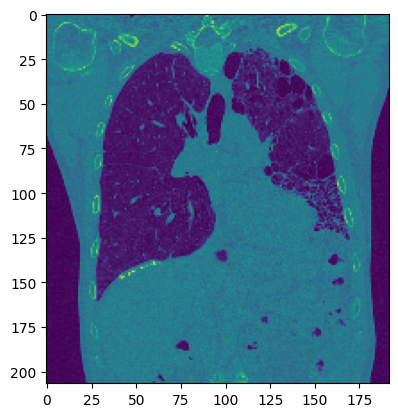

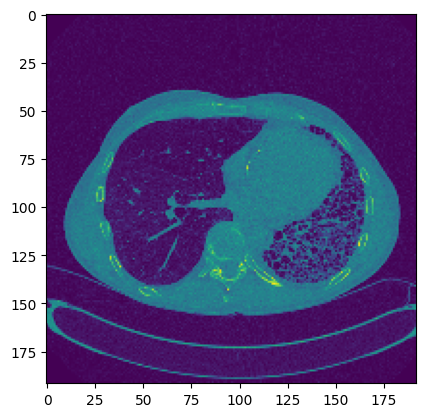

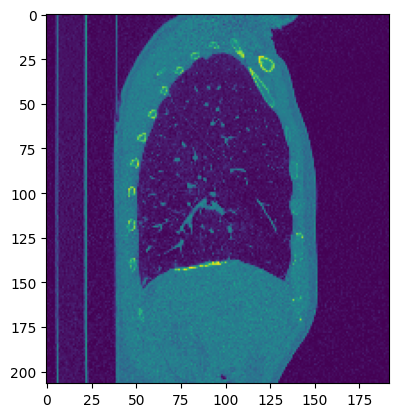

In [ ]:
#let's view these three slices from this imaging volume
plt.imshow(sliceA_breathholdX)
plt.show()

plt.imshow(sliceB_breathholdX)
plt.show()

plt.imshow(sliceC_breathholdX)
plt.show()

**Question 4: What orientation are the three slices in?**

YOUR ANSWER:
1.   sliceA_breathholdX is in axialorientation
2.   sliceB_breathholdX is in coronal orientation
3.   sliceC_breathholdX is in sagittal orientation

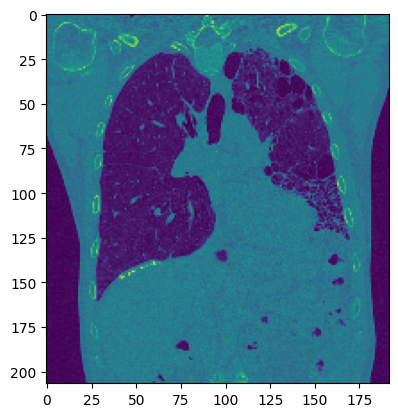

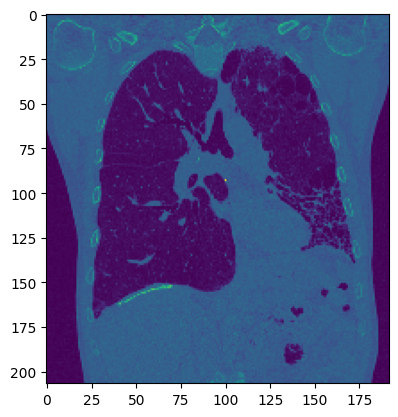

In [ ]:
#let's now determine and label for the files for their breath hold
sliceA_breathholdX = np.rot90(subject001_X_volume[:,98,:]) #either inspiration or expiration, X or Y
sliceA_breathholdY = np.rot90(subject001_Y_volume[:,98,:]) #slicing will depend on the patient's size and stuff

plt.imshow(sliceA_breathholdX)
plt.show()

plt.imshow(sliceA_breathholdY)
plt.show()

**Question 5: Which file was acquired at inspiration? Expiration?**

YOUR ANSWER:

subject001_BreathHoldX.nii.gz was taken at expiration.

subject001_BreathHoldY.nii.gz was taken at inspiration.

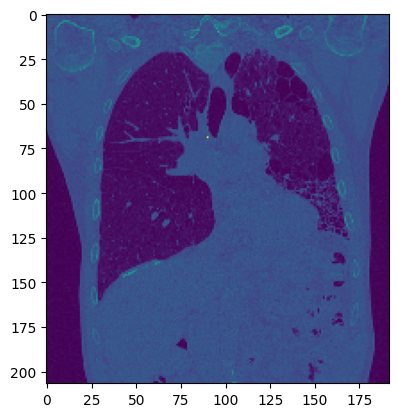

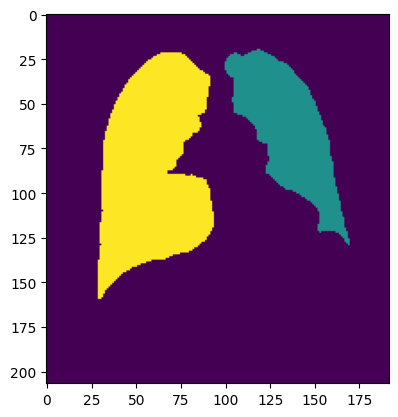

The unique values in the lung mask are [0. 1. 2.]


In [ ]:
#now let's segment the lungs from the images
# if you're interested see this github link for an automatic AI model that will segment lungs from HRCTs: https://github.com/JoHof/lungmask

# for today's exercise, the lungs have already been segmented for you and saved as additional files in the folder
subject001_X_lungmask = nib.load(folder + 'subject001_BreathHoldX_LungMask.nii.gz').get_fdata()
#prev: seperating metadata from other stuff

sliceA_breathholdX = np.rot90(subject001_X_volume[:,100,:])
sliceA_breathholdX_lungmask = np.rot90(subject001_X_lungmask[:,100,:])

plt.imshow(sliceA_breathholdX)
plt.show()

plt.imshow(sliceA_breathholdX_lungmask)
plt.show()

# what are the values in the lung mask?
print('The unique values in the lung mask are {}'.format(np.unique(sliceA_breathholdX_lungmask)))
#think of the mask as a filter to get the characterisitcs we want
#output: 0 is background, 1 is left lung and 2 is three
#can convert 1 and 2 to just 1 and leave everything else as zero
#np.where

**Question 6: What do you think the different colors represent in this lung mask? Do you think it did a good job at segmenting the lungs?**

YOUR ANSWER: the right lung is the yellow and the left lung is the blue ! It's a mirror image.

**Question 7: Can you build a pre-processing pipeline?**
For this question, you will need to fill in the code for the following 3 cells that will:
1.   segment the lungs
2.   resample the resolution to 4 x 4 x 4 mm^3
3.   normalize the pixel values from 0 to 1

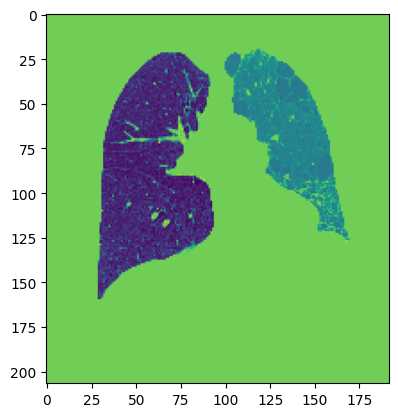

In [ ]:
# Question 7, part 1: segment the lungs
# HINT: right now the lung mask holds 3 unique values 0, 1, 2.
# First, change this so everything that is not lung is 0 and everything that is lung is 1
# Second, multiple the two numpy arrays together such that you only lung tissue in the end
import numpy as np

segmented_lung = np.where (subject001_X_lungmask > 0, 1, 0)
input =  subject001_X_volume * subject001_X_lungmask
plt.imshow(np.rot90(input[:,100,:]))
plt.show()

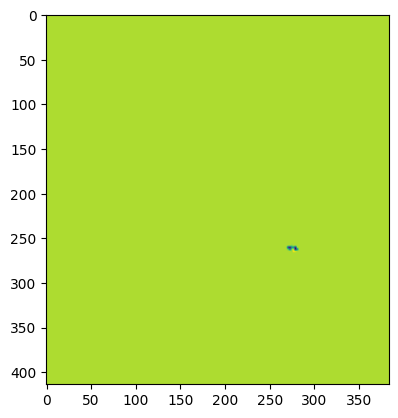

In [ ]:
# Question 7, part 2: resample the resolution to 4 x 4 x 4 mm^3
# HINT: use the zoom function from scipy
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.zoom.html#scipy.ndimage.zoom
# Question 7, part 2: resample the resolution to 4 x 4 x 4 mm^3
# HINT: use the zoom function from scipy
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.zoom.html#scipy.ndimage.zoom
from scipy.ndimage import zoom

new_image = zoom(input, (2, 2, 2), order=1, mode='constant', cval=0.0, prefilter=True, grid_mode=False)
plt.imshow(np.rot90(new_image[:,100,:]))
plt.show()

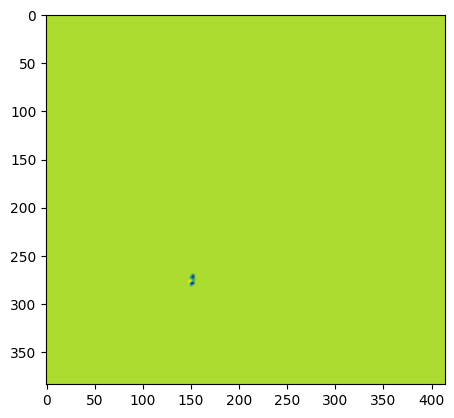

In [ ]:
# Question 7, part 3: normalize the pixel values from 0 to 1
# HINT: Find the min and max pixel values to scale accordingly
min_pixel = np.min(new_image)
max_pixel = np.max(new_image)
normalized_image = (new_image - min_pixel) / (max_pixel - min_pixel)

plt.imshow(normalized_image[:, 100, :])
plt.show()